In [1]:
import os
import h5py
import pandas as pd
import mne
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
eeg_path = "/home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH"
order_path = "/home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/stimuli/Stimulus_Orders"

screen_size = (2560, 1440)
# screen_size = (2155, 1440)
image_size = (2155, 1440)
ap = screen_size[0] / screen_size[1]
# ap, 16/9

# saccade_cutoff = (image_size[0] * 0.05, image_size[1] * 0.05)
saccade_cutoff = (screen_size[0] * 0.05, screen_size[1] * 0.05)

In [ ]:
def get_sub_data(sub, session, verbose:bool=True):
    # sub = 18
    data_dir = f'/home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH/sub{str(sub).zfill(3)}'
    
    ses = f'ses00{session}'

    filenames = [x for x in os.listdir(data_dir) if x.endswith('.hdf5') and f'sub{str(sub).zfill(3)}_{ses}' in x]

    # filename = os.path.join(data_dir, f'sub{str(sub).zfill(3)}_{ses}.hdf5')
    df = []
    for filename in filenames:
        with h5py.File(os.path.join(data_dir, filename), 'r') as f:
            data = f['data_collection']['events']['eyetracker']['BinocularEyeSampleEvent'][:]
            df.append(pd.DataFrame(data))

    df = pd.concat(df, ignore_index=True)

    # sub = 'sub010'
    subses_name = f"sub{sub:03d}_{ses}"


    #get data info
    all_timings = {}
    for cond in ['size1', 'size2', 'size3', 'center1', 'center2', 'center3', 'peri1', 'peri2', 'peri3']:
        raw = mne.io.read_raw_bdf(os.path.join(eeg_path, f'sub{sub:03d}', subses_name + ".bdf"), verbose=verbose) #subses_name
        fif = mne.read_epochs(f'/home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH_manual/fif_files/{subses_name}{cond}-OC&CSD-epo.fif', verbose=verbose)
        timing_indices = fif.events[:, 0]
        timings = [raw.times[i] for i in timing_indices]
        all_timings[cond] = timings

    return df, all_timings #, raw, fif, subses_name

In [4]:
def get_saccade_summary(df, timings, pre_onset=-0.1, post_onset=0.4, spatial_cutoff=0.05):
    counts = []
    # saccades = []
    saccade_counts = []
    reject = []
    is_saccades = []
    # times = []

    trial_saccades = []

    for image_onset in timings:
        count = 0
        saccade_count = 0
        saccades = []
        times = []
        is_saccade = []
        for _, row in df[(df['time'] > image_onset + pre_onset) & (df['time'] < image_onset + post_onset)].iterrows():
            x = row['right_gaze_x'] # height units
            y = row['right_gaze_y'] # height units

            # print(x, y)

            ####### x = x * screen_size[0]
            ####### y = y * screen_size[1] * ap
            # x = x * screen_size[0] * ap
            # y = y * screen_size[1]
            # if np.abs(x) > saccade_cutoff[0] or np.abs(y) > saccade_cutoff[1]: # and row['time'] > image_onset + pre_onset and row['time'] < image_onset + post_onset:

            x = x * ap
            
            if np.abs(x) > spatial_cutoff or np.abs(y) > spatial_cutoff and row['time'] > image_onset and row['time'] < image_onset + 0.05:
                # saccades.append((x, y))
                saccade_count += 1
                is_saccade.append(True)
            #     saccades.append((x,y))
            else:
                is_saccade.append(False)
                
            #     saccades.append(None)
                # times.append(None)
            # y = y * ap
            saccades.append((x,y))
            times.append(row['time'] - image_onset)

            count += 1

        # if saccade_count > 0.2*count:
        if saccade_count > 0:
            reject.append(True)
        else:
            reject.append(False)
            
        counts.append(count)
        saccade_counts.append(saccade_count)
        trial_saccades.append((saccades, times))
        is_saccades.append(is_saccade)

    # return counts, saccades, saccade_counts, reject, times
    return counts, trial_saccades, saccade_counts, reject, is_saccades

In [ ]:
rows = []
cols = ['subject', 'session', 'condition', 'spatial_cutoff', 'percent_saccade', 'percent_fixation']

for sub in [12, 15, 16, 17, 18, 19]:
    for session in range(1, 7):
        try:
            df, all_timings = get_sub_data(sub, session)
            for row_index, condition in enumerate(all_timings.keys()):
                for spatial_cutoff in [0.01, 0.025, 0.05, 0.075, 0.1]:
                    counts, saccades, saccade_counts, reject, is_saccades = get_saccade_summary(df, all_timings[condition], pre_onset=0, post_onset=0.1, spatial_cutoff=spatial_cutoff)
                    n_saccade_trial = sum([1 for x in reject if x])
                    n_fixation_trial = sum([1 for x in reject if not x])

                    percent_saccade = n_saccade_trial / len(reject)
                    percent_fixation = n_fixation_trial / len(reject)

                    rows.append([sub, session, condition, spatial_cutoff, percent_saccade, percent_fixation])

            df = pd.DataFrame(rows, columns=cols)
            df.to_parquet('./saccade_summary.parquet', index=False)
        except:
            print(f"Error in subject {sub}, session {session}, condition {condition} with spatial cutoff {spatial_cutoff}")
            # continue

Extracting EDF parameters from /home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH/sub012/sub012_ses001.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading /home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH_manual/fif_files/sub012_ses001size1-OC&CSD-epo.fif ...
    Found the data of interest:
        t =     -99.61 ...     400.39 ms
        0 CTF compensation matrices available
Not setting metadata
720 matching events found
No baseline correction applied
0 projection items activated
Extracting EDF parameters from /home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH/sub012/sub012_ses001.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading /home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_

In [ ]:
df = pd.DataFrame(rows, columns=cols)
df.to_parquet('./saccade_summary.parquet', index=False)

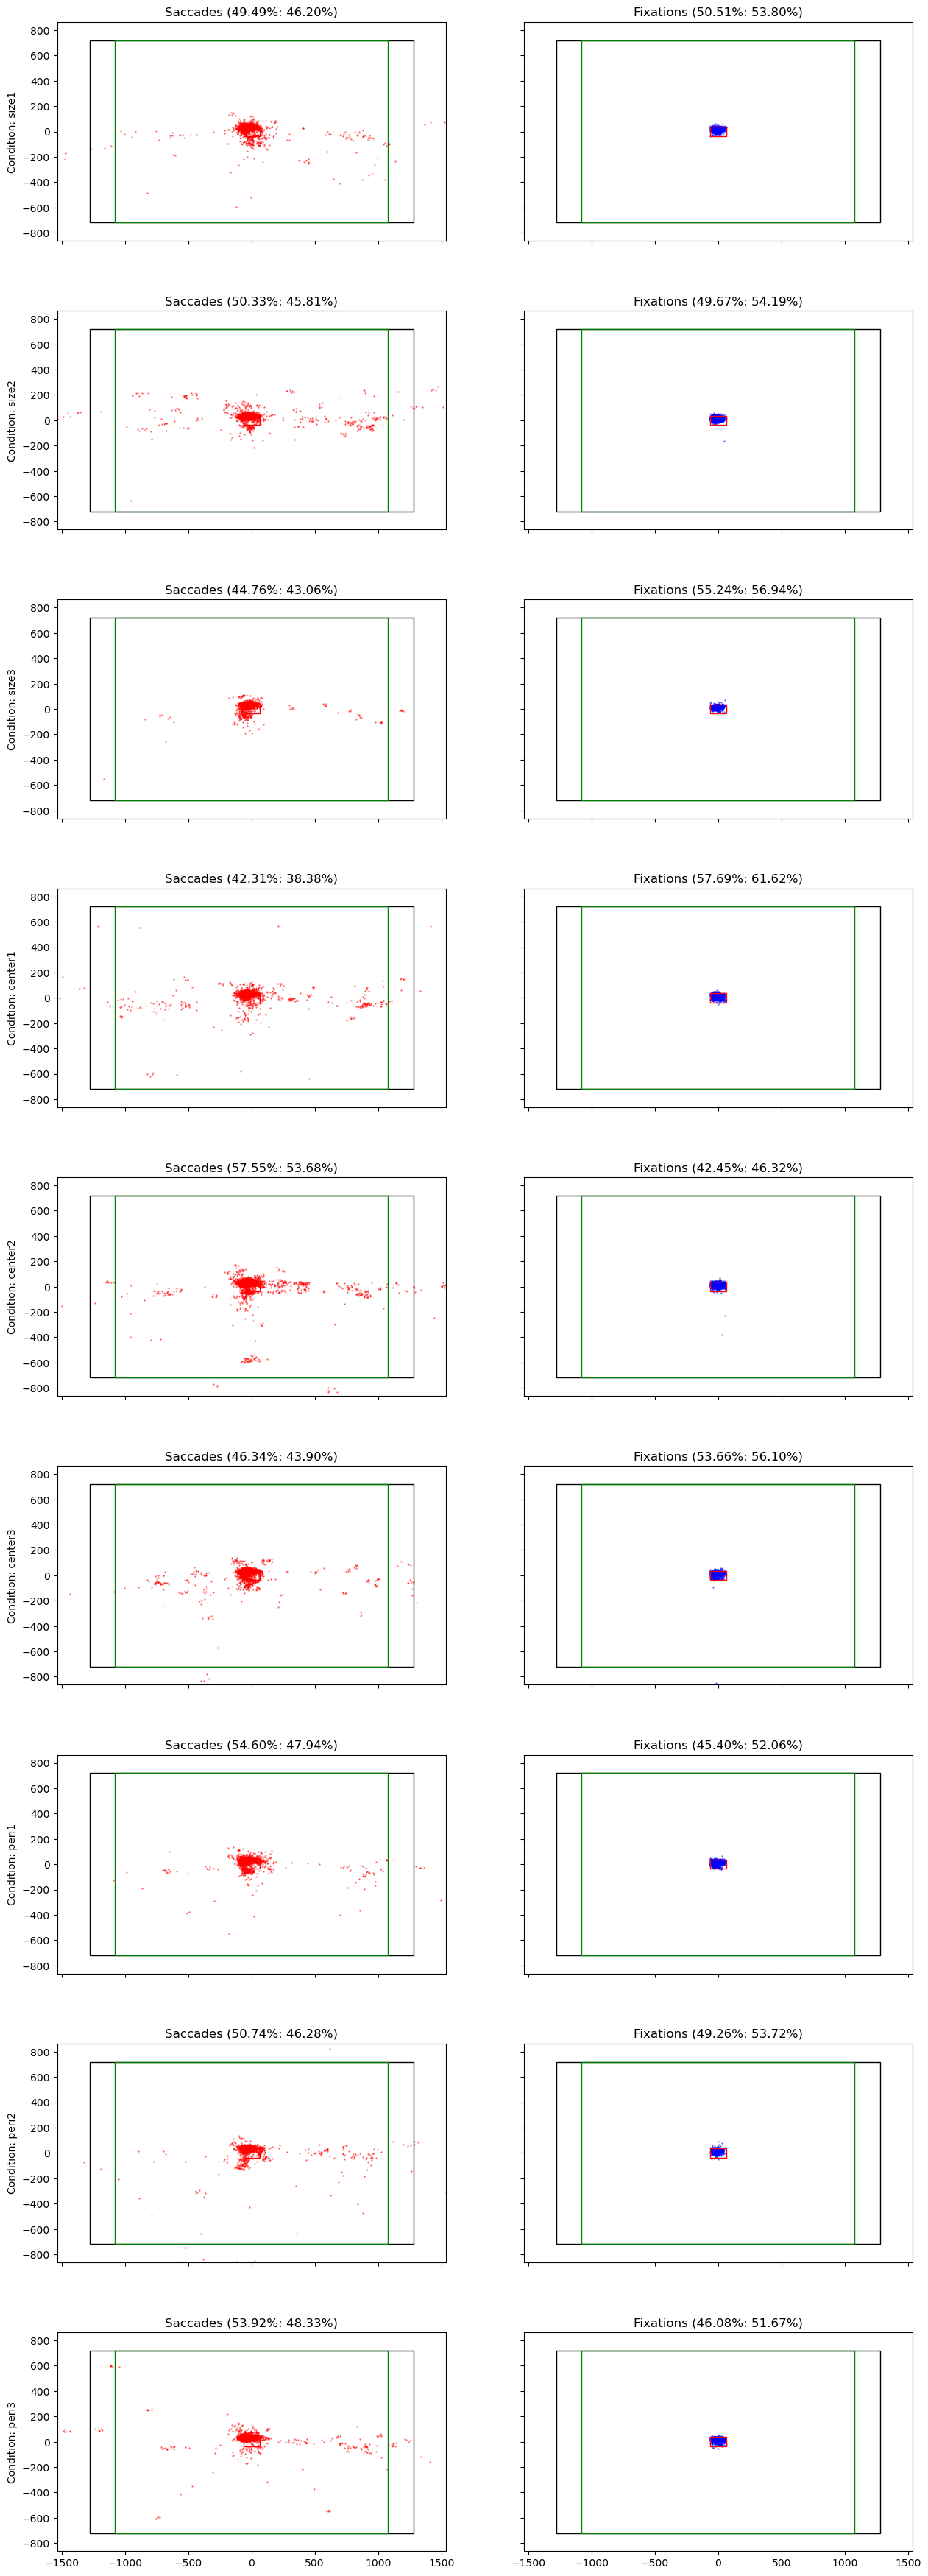

In [25]:
# condition = 'size3'
fig, ax = plt.subplots(len(all_timings), 2, figsize=(15, 5*len(all_timings)), sharex=True, sharey=True)

for row_index, condition in enumerate(all_timings.keys()):
    counts, saccades, saccade_counts, reject, is_saccades = get_saccade_summary(df, all_timings[condition], pre_onset=0, post_onset=0.1)

    fixation_coords = []
    saccade_coords = []

    for onset, check, rej in zip(saccades, is_saccades, reject):
        for saccade, is_saccade in zip(onset[0], check):
            # if is_saccade:
            #     saccade_coords.append(saccade)
            # else:
            #     fixation_coords.append(saccade)
            if rej:
                saccade_coords.append(saccade)
            else:
                fixation_coords.append(saccade)
                
    saccade_coords = np.array(saccade_coords)
    fixation_coords = np.array(fixation_coords)


    ax[row_index, 0].scatter(saccade_coords[:, 0] * screen_size[0], saccade_coords[:, 1] * screen_size[1], color='red', alpha=0.5, s=0.5)

    ax[row_index, 1].scatter(fixation_coords[:, 0] * screen_size[0], fixation_coords[:, 1] * screen_size[1], color='blue', alpha=0.5, s=0.5)

    rect = plt.Rectangle((-spatial_cutoff * screen_size[0], -spatial_cutoff * screen_size[1]), screen_size[0] * 2*spatial_cutoff, screen_size[1] * 2*spatial_cutoff, linewidth=1, edgecolor='red', facecolor='none')
    ax[row_index, 0].add_patch(rect)
    rect = plt.Rectangle((-spatial_cutoff * screen_size[0], -spatial_cutoff * screen_size[1]), screen_size[0] * 2*spatial_cutoff, screen_size[1] * 2*spatial_cutoff, linewidth=1, edgecolor='red', facecolor='none')
    ax[row_index, 1].add_patch(rect)
    rect = plt.Rectangle((-0.5 * screen_size[0], -0.5 * screen_size[1]), screen_size[0], screen_size[1], linewidth=1, edgecolor='black', facecolor='none')
    ax[row_index, 0].add_patch(rect)
    rect = plt.Rectangle((-0.5 * screen_size[0], -0.5 * screen_size[1]), screen_size[0], screen_size[1], linewidth=1, edgecolor='black', facecolor='none')
    ax[row_index, 1].add_patch(rect)
    rect = plt.Rectangle((-0.5 * image_size[0], -0.5 * image_size[1]), image_size[0], image_size[1], linewidth=1, edgecolor='green', facecolor='none')
    ax[row_index, 0].add_patch(rect)
    rect = plt.Rectangle((-0.5 * image_size[0], -0.5 * image_size[1]), image_size[0], image_size[1], linewidth=1, edgecolor='green', facecolor='none')
    ax[row_index, 1].add_patch(rect)

    n_saccade_trial = sum([1 for x in reject if x])
    n_fixation_trial = sum([1 for x in reject if not x])

    ax[row_index, 0].set_title(f'Saccades ({len(saccade_coords) / (len(saccade_coords) + len(fixation_coords)):.2%}: {n_saccade_trial / len(reject):.2%})')
    ax[row_index, 1].set_title(f'Fixations ({len(fixation_coords) / (len(saccade_coords) + len(fixation_coords)):.2%}: {n_fixation_trial / len(reject):.2%})')

    ax[row_index, 0].set_xlim(screen_size[0] * -0.6, screen_size[0] * 0.6)
    ax[row_index, 0].set_ylim(screen_size[1] * -0.6, screen_size[1] * 0.6)
    ax[row_index, 0].set_aspect('equal')
    ax[row_index, 1].set_xlim(screen_size[0] * -0.6, screen_size[0] * 0.6)
    ax[row_index, 1].set_ylim(screen_size[1] * -0.6, screen_size[1] * 0.6)
    ax[row_index, 1].set_aspect('equal')

    ax[row_index, 0].set_ylabel(f'Condition: {condition}')

plt.show()

In [118]:
saccade_show = np.zeros((screen_size[1], screen_size[0]))
fixation_show = np.zeros((screen_size[1], screen_size[0]))

for condition in all_timings.keys():

    counts, saccades, saccade_counts, reject, is_saccades = get_saccade_summary(df, all_timings[condition])

    fixation_coords = []
    saccade_coords = []

    for onset, check in zip(saccades, is_saccades):
        for saccade, is_saccade in zip(onset[0], check):
            if is_saccade:
                saccade_coords.append(saccade)
            else:
                fixation_coords.append(saccade)
                
    saccade_coords = np.array(saccade_coords)
    fixation_coords = np.array(fixation_coords)


    for saccade in saccade_coords:
        x, y = saccade
        x = int(x * screen_size[0]) + screen_size[0] // 2
        y = int(y * screen_size[1]) + screen_size[1] // 2

        # x = int(x * screen_size[0])
        # y = int(y * screen_size[1] * ap)
        if x >= 0 and x < screen_size[0] and y >= 0 and y < screen_size[1]:
            # saccade_show[y, x] = (1, 0, 0)
            saccade_show[y, x] += 1

    for fixation in fixation_coords:
        x, y = fixation
        if np.isnan(x) or np.isnan(y):
            continue
        x = int(x * screen_size[0]) + screen_size[0] // 2
        y = int(y * screen_size[1]) + screen_size[1] // 2
        
        if x >= 0 and x < screen_size[0] and y >= 0 and y < screen_size[1]:
            # fixation_show[y, x] = (0, 1, 0)
            fixation_show[y, x] += 1

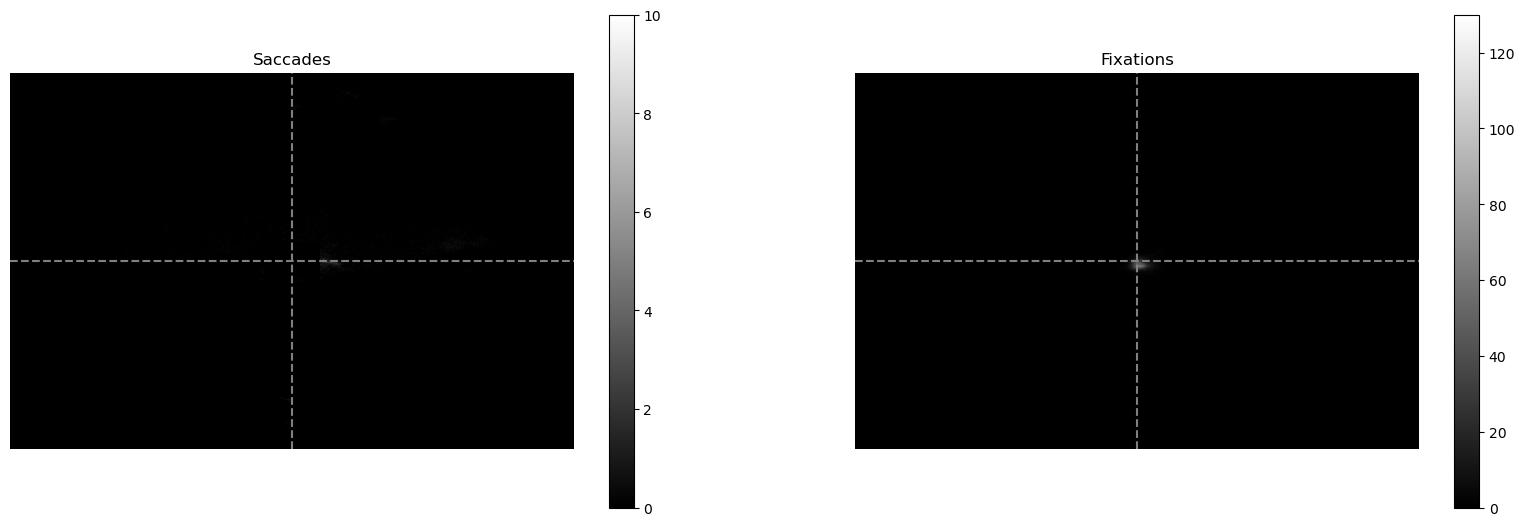

In [119]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

im = ax[0].imshow(saccade_show, cmap='gray')
plt.colorbar(im, ax=ax[0], orientation='vertical', shrink=0.8)
ax[0].set_title('Saccades')
ax[0].axis('off')
ax[0].axhline(screen_size[1] // 2, color='gray', linestyle='--')
ax[0].axvline(screen_size[0] // 2, color='gray', linestyle='--')
ax[0].set_aspect('equal')

im = ax[1].imshow(fixation_show, cmap='gray')
plt.colorbar(im, ax=ax[1], orientation='vertical', shrink=0.8)
ax[1].set_title('Fixations')
ax[1].axis('off')
ax[1].axhline(screen_size[1] // 2, color='gray', linestyle='--')
ax[1].axvline(screen_size[0] // 2, color='gray', linestyle='--')
ax[1].set_aspect('equal')

plt.show()

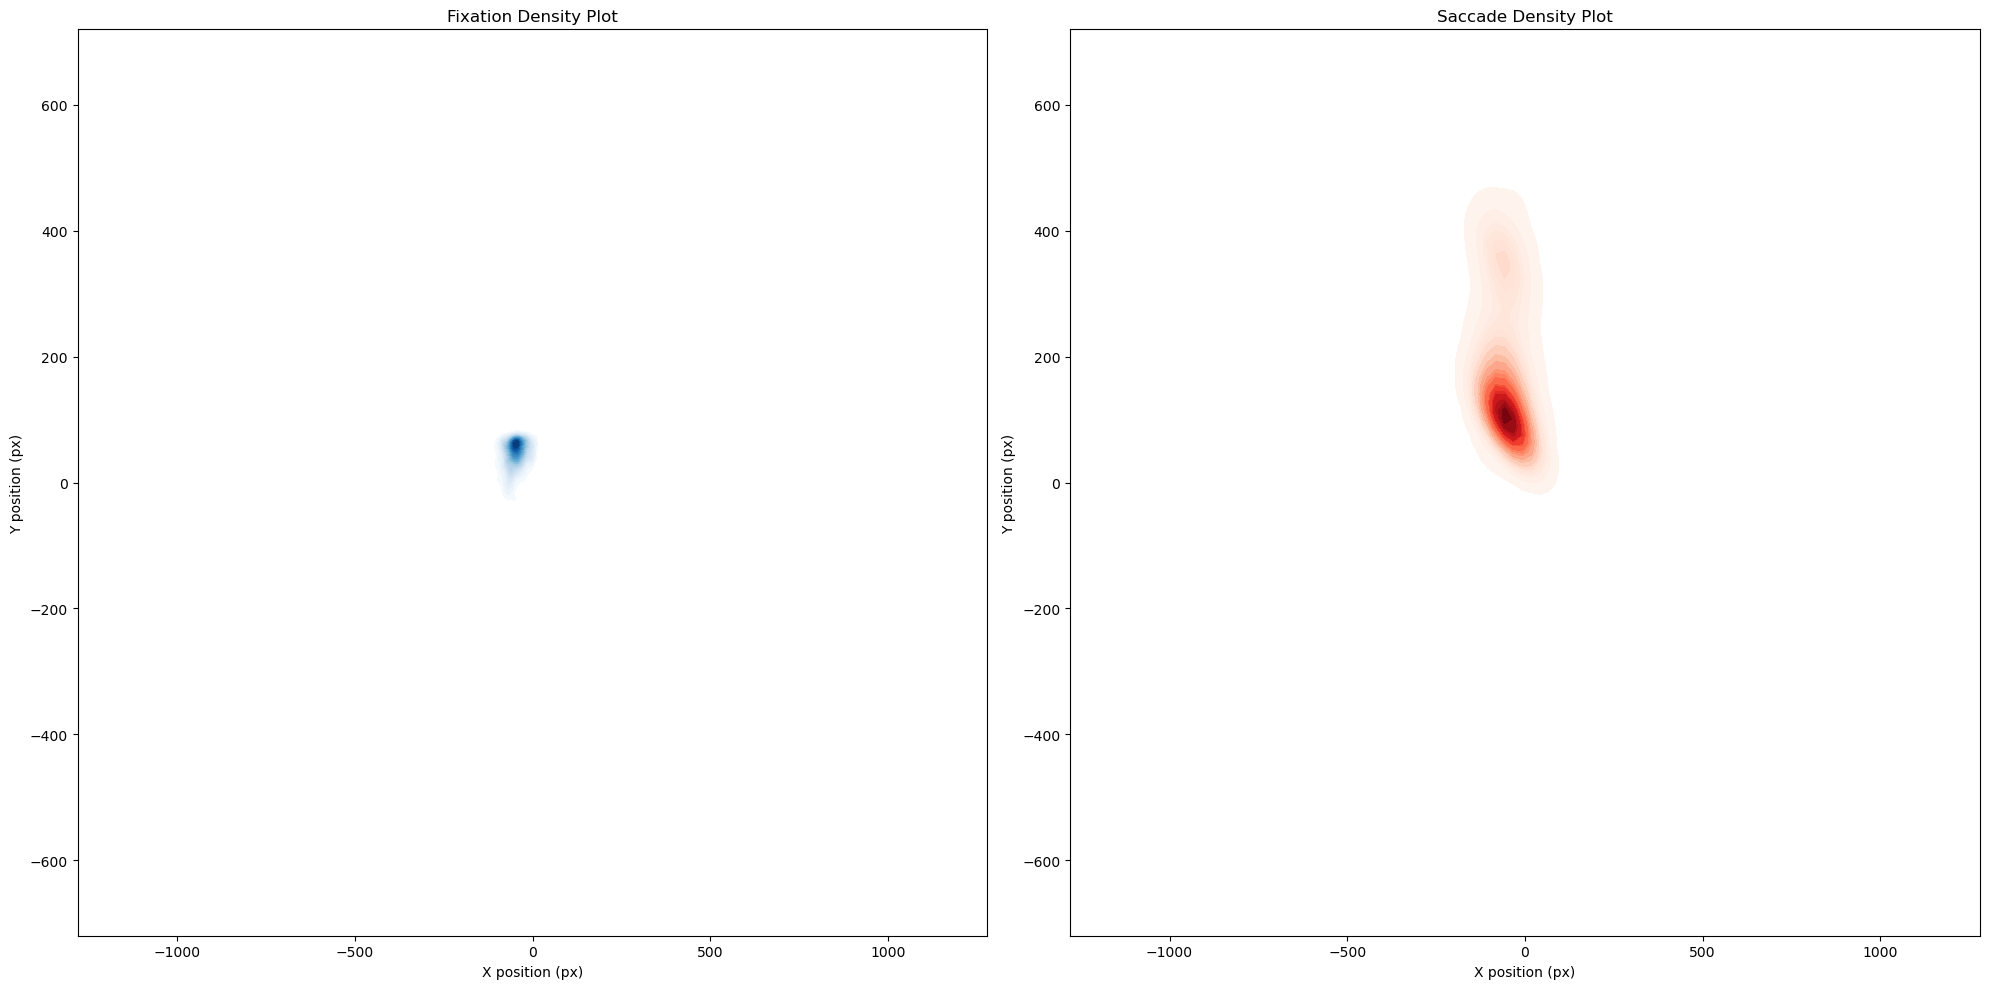

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# sns.kdeplot(x=l[:, 0], y=l[:, 1], ax=ax, cmap='Blues', fill=True, thresh=0.05, levels=20)
sns.kdeplot(x=fixation_coords[:, 0], y=fixation_coords[:, 1], ax=ax[0], cmap='Blues', fill=True, thresh=0.05, levels=20)
sns.kdeplot(x=saccade_coords[:, 0], y=saccade_coords[:, 1], ax=ax[1], cmap='Reds', fill=True, thresh=0.05, levels=20)
ax[0].set_title('Fixation Density Plot')
ax[1].set_title('Saccade Density Plot')
ax[0].set_xlim(-screen_size[0] / 2, screen_size[0] / 2)
ax[0].set_ylim(-screen_size[1] / 2, screen_size[1] / 2)
ax[1].set_xlim(-screen_size[0] / 2, screen_size[0] / 2)
ax[1].set_ylim(-screen_size[1] / 2, screen_size[1] / 2)
ax[0].set_xlabel('X position (px)')
ax[0].set_ylabel('Y position (px)')
ax[1].set_xlabel('X position (px)')
ax[1].set_ylabel('Y position (px)')


plt.tight_layout()
plt.show()

In [ ]:
# df, timings, raw, fif, subses_name = get_sub_data(12, 2, cond='size1', verbose=False)

In [179]:
# counts, saccades, saccade_counts, reject, times = get_saccade_summary(df, all_timings['size1'], pre_onset=-0.1, post_onset=0.4)
rows = []
cols = ['trial', 'condition', 'time', 'saccade']

for condition in all_timings.keys():

    counts, trial_saccades, saccade_counts, reject = get_saccade_summary(df, all_timings[condition], pre_onset=-0.1, post_onset=0.4)
    fraction_rejected = np.mean(reject)

    # for saccades, times in trial_saccades:
    saccades = [[] for _ in range(60)]
    times = [[] for _ in range(60)]


    for trial_index, trial in enumerate(trial_saccades):

        for counter, idx in enumerate(np.argsort(trial[1])):
            time = trial[1][idx]
            sac = trial[0][idx]
            
            if counter >= 60:
                continue

            if sac is not None:
                saccades[counter].append(0)
            else:
                saccades[counter].append(1)

            times[counter].append(time)

            rows.append([trial_index, condition, time, saccades[counter][-1]])

In [180]:
sac_df = pd.DataFrame(rows, columns=cols)

In [181]:
sac_df['binned_times'] = pd.cut(sac_df['time'], bins=np.linspace(-0.1, 0.4, 60)).apply(lambda x: x.mid)

In [182]:
sac_df

,trial,condition,time,saccade,binned_times
0,0,size1,-0.092536,1,-0.09575
1,0,size1,-0.089554,1,-0.08730
2,0,size1,-0.075868,1,-0.07885
3,0,size1,-0.072883,1,-0.07035
4,0,size1,-0.059199,1,-0.06185
...,...,...,...,...,...
111542,414,peri3,0.318554,0,0.31950
111543,414,peri3,0.335218,0,0.33650
111544,414,peri3,0.351889,0,0.35350
111545,414,peri3,0.368557,0,0.37050


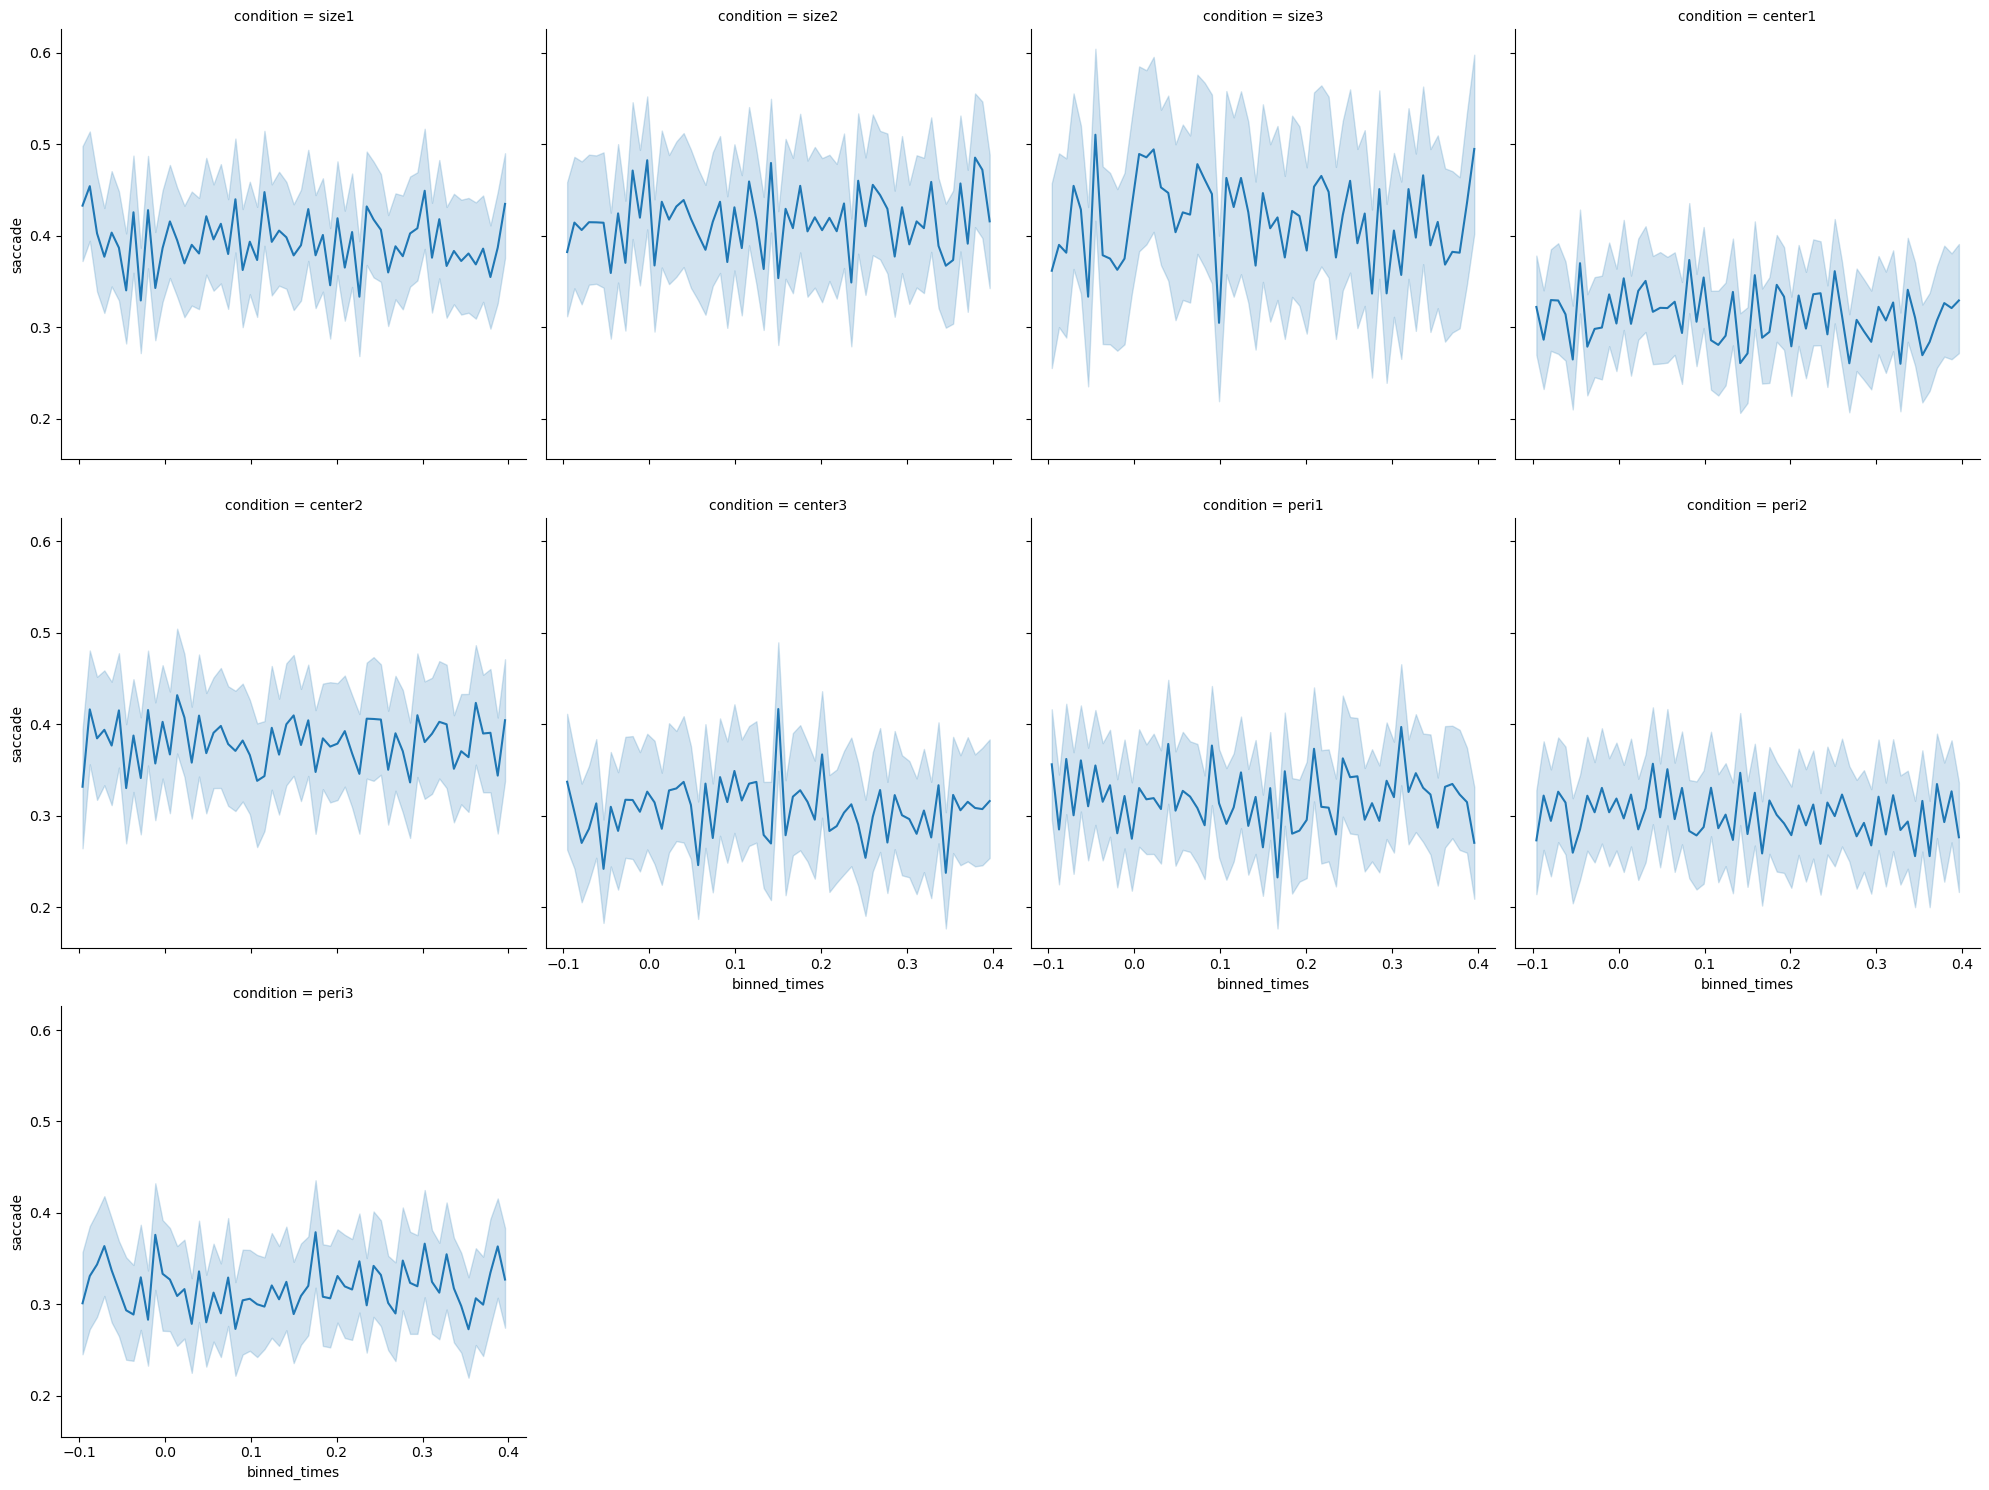

In [183]:
g = sns.relplot(data=sac_df, x='binned_times', y='saccade', col='condition', kind='line', col_wrap=4)

plt.show()

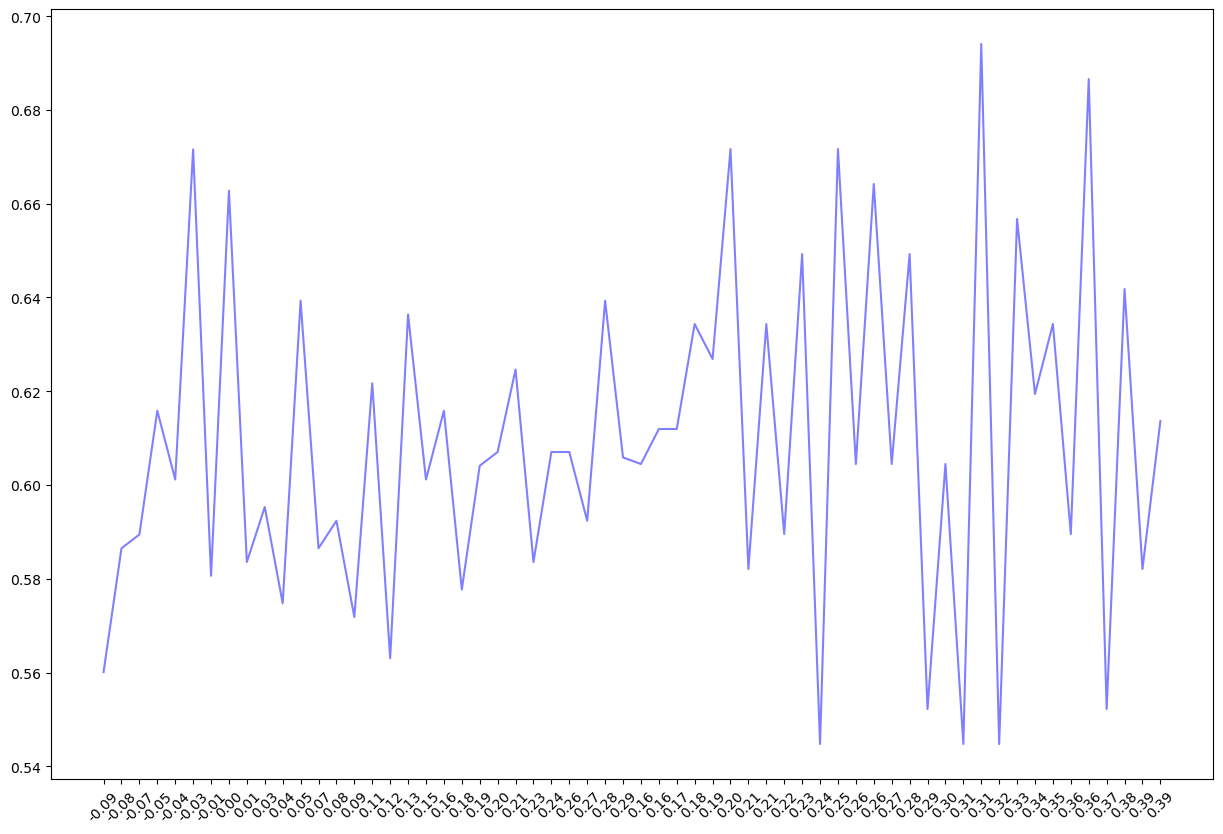

In [91]:

fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# ax.plot([np.mean(x) for x in times], [np.mean(x) for x in saccades], color='blue', alpha=0.5)
ax.plot(range(60), [np.mean(x) for x in saccades], color='blue', alpha=0.5)

ax.set_xticks(range(60), [f"{np.mean(x):.2f}" for x in times], rotation=45)

plt.show()

In [54]:
idx

60

/tmp/ipykernel_861670/361174277.py:5: RuntimeWarning: invalid value encountered in divide
  ax.plot(saccade_counts / np.array(counts) * 100)


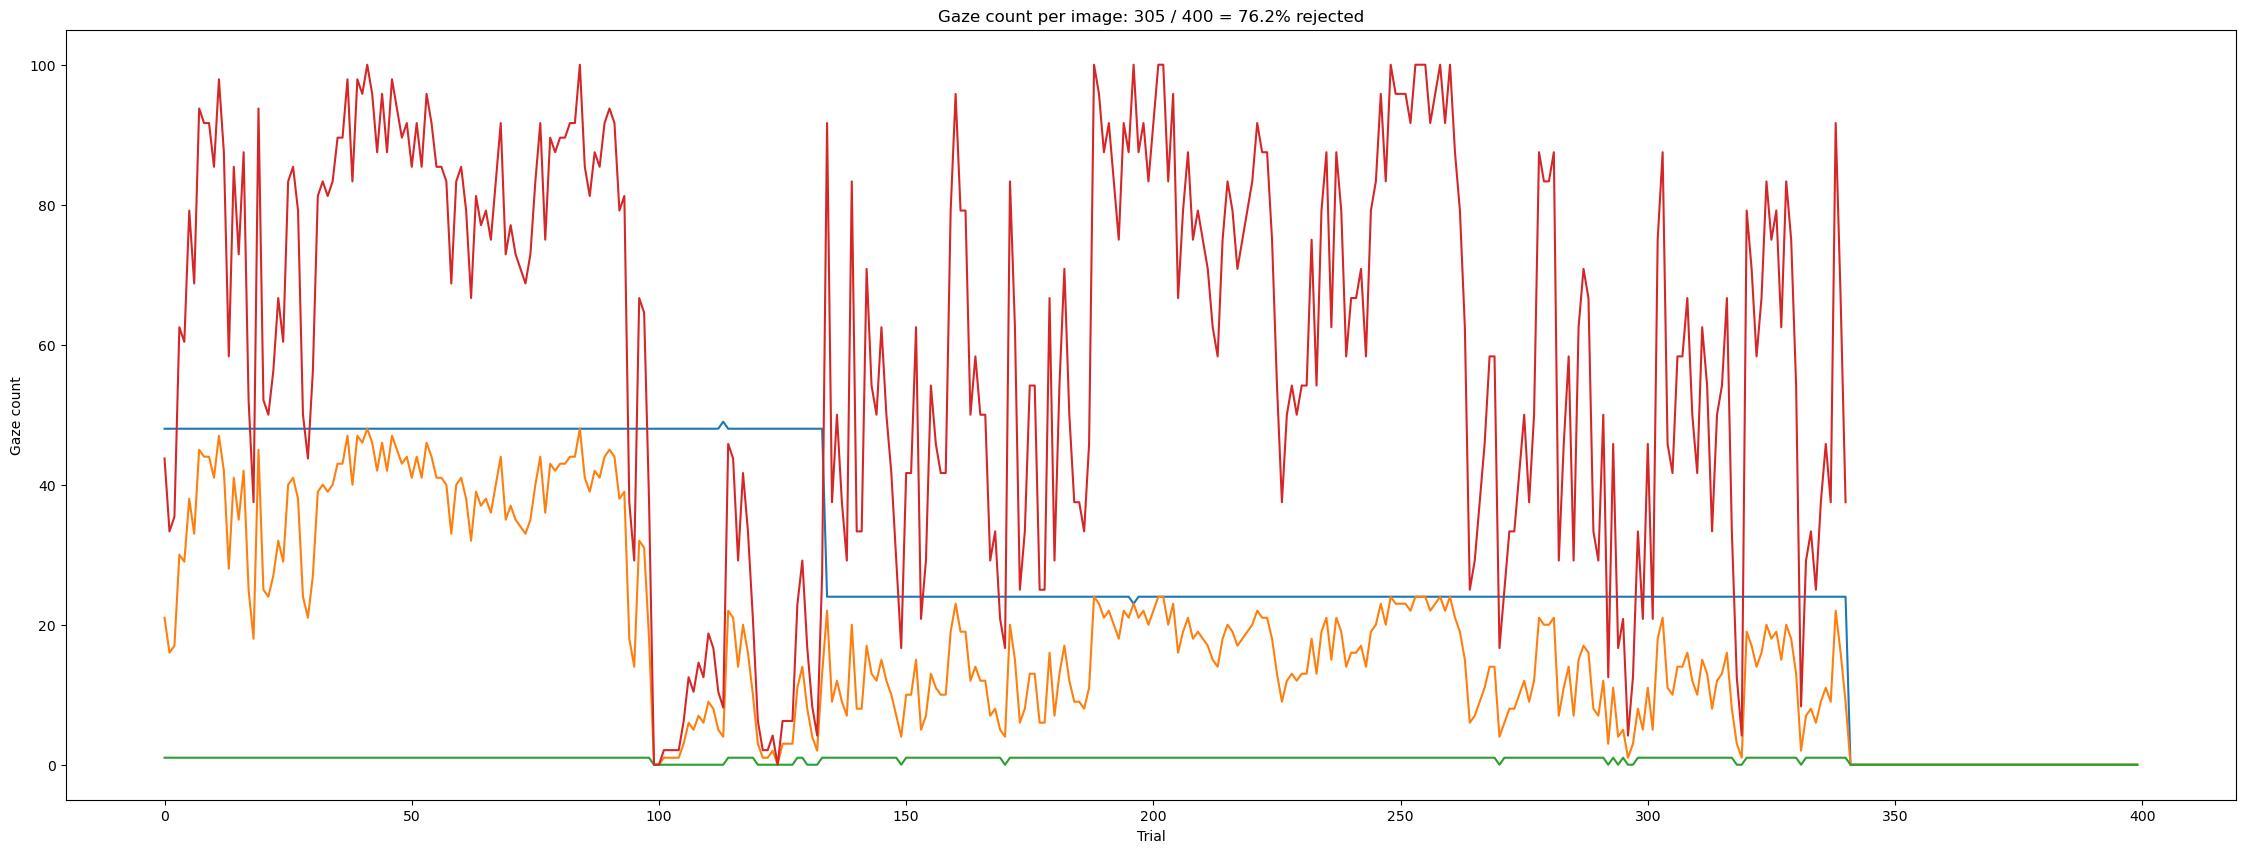

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(28, 10))
ax.plot(counts)
ax.plot(saccade_counts)
ax.plot(reject)
ax.plot(saccade_counts / np.array(counts) * 100)
ax.set_title(f'Gaze count per image: {sum(reject)} / {len(reject)} = {fraction_rejected:.1%} rejected')
ax.set_xlabel('Trial')
ax.set_ylabel('Gaze count')
plt.show()

In [ ]:
recs = {}
for cond in all_timings.keys():
    recs[cond] = []
    for x in np.linspace(-0.1, 0.39, 25):
        counts, saccades, saccade_counts, reject = get_saccade_summary(df, all_timings[cond], pre_onset=x, post_onset=x+0.01)
        # fraction_rejected = np.mean(reject)
        # recs[cond].append(fraction_rejected)
        recs[cond].append(saccade_counts / np.array(counts) * 100)

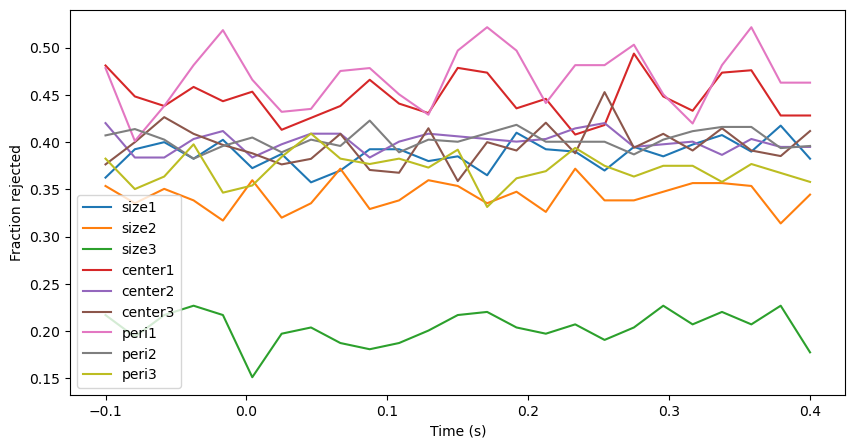

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
for cond, rec in recs.items():
    ax.plot(np.linspace(-0.1, 0.4, 25), rec, label=cond)
# ax.plot(np.linspace(-0.1, 0.4, 25), recs)
# ax.set_title(f'Gaze count per image: {sum(reject)} / {len(reject)} = {fraction_rejected:.1%} rejected')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Fraction rejected')
ax.legend()
plt.show()

In [6]:
from tqdm import tqdm
# rows = []
# cols = ['subject', 'session', 'condition', 'fraction_rejected']

cols = ['subject', 'session', 'condition', 'trial_number', 'reject', 'saccade_count', 'count']
subjects = [19] # 12, 15, 16, 17, 18, 19]
for sub in tqdm(subjects, total=len(subjects)):
    for session in range(1, 7):
        rows = []
        try:
            df, all_timings = get_sub_data(sub, session=session, verbose=False)
        except IndexError as e:
            print(f"Error processing subject {sub}, session {session}:\n\n{e}")
            continue
        
        for cond, timings in all_timings.items():
            try:
                counts, saccades, saccade_counts, reject = get_saccade_summary(df, timings)
                for trial_number, r, saccade_count, count in zip(range(len(reject)), reject, saccade_counts, counts):
                    rows.append([sub, session, cond, trial_number, r, saccade_count, count])

                # fraction_rejected = np.mean(reject)
                # rows.append([sub, session, cond, fraction_rejected])
            except Exception as e:
                print(f"Error processing subject {sub}, session {session}, condition {cond}:\n\n{e}")
                continue

        df = pd.DataFrame(rows, columns=cols)

        df.to_parquet(f'./trail_rejection_sub{sub}-ses{session}.parquet')

100%|██████████| 1/1 [16:04<00:00, 964.75s/it]


In [19]:
df.to_parquet(f'./saccade_rejection_all_subjects_second_batch.parquet')

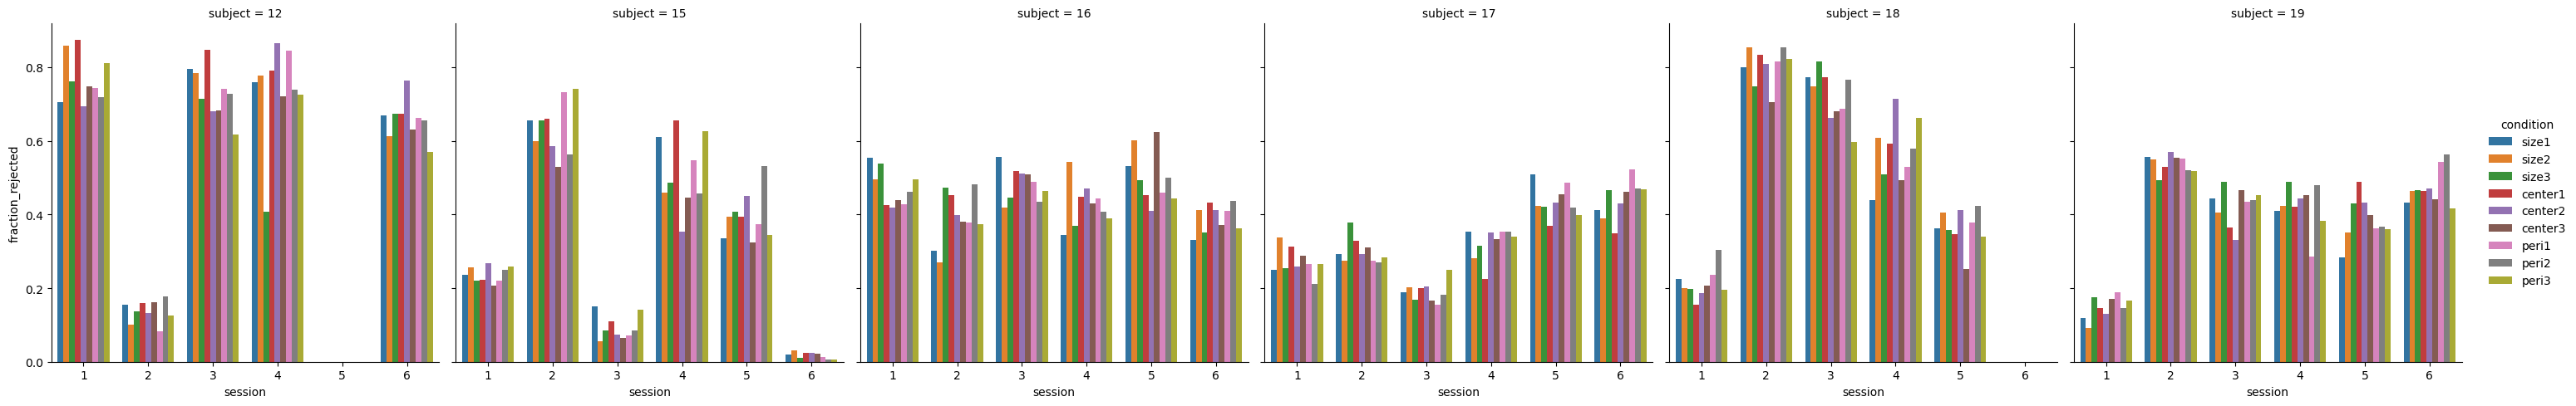

In [16]:
g = sns.catplot(data=df, x='session', y='fraction_rejected', hue='condition', col='subject', kind='bar')

plt.show()

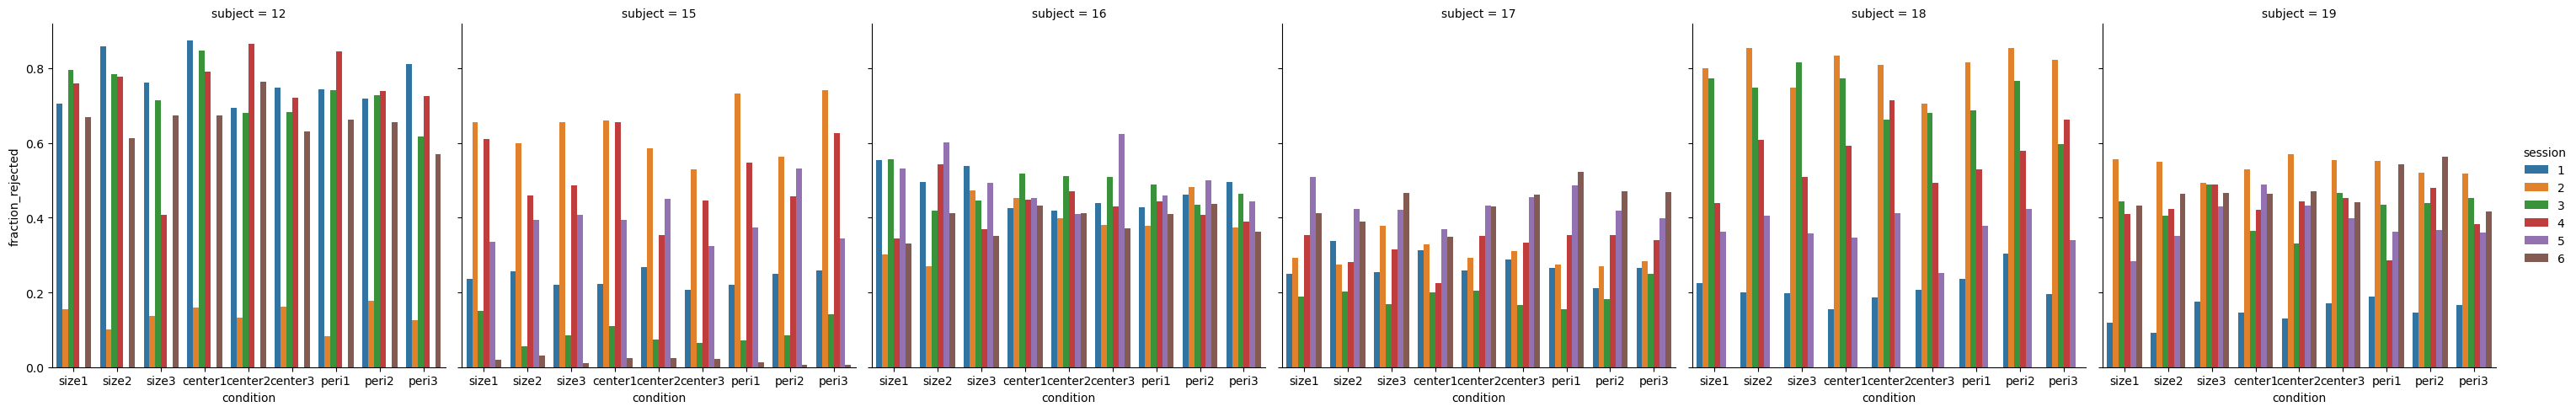

In [17]:
g = sns.catplot(data=df, x='condition', y='fraction_rejected', hue='session', col='subject', kind='bar')

plt.show()

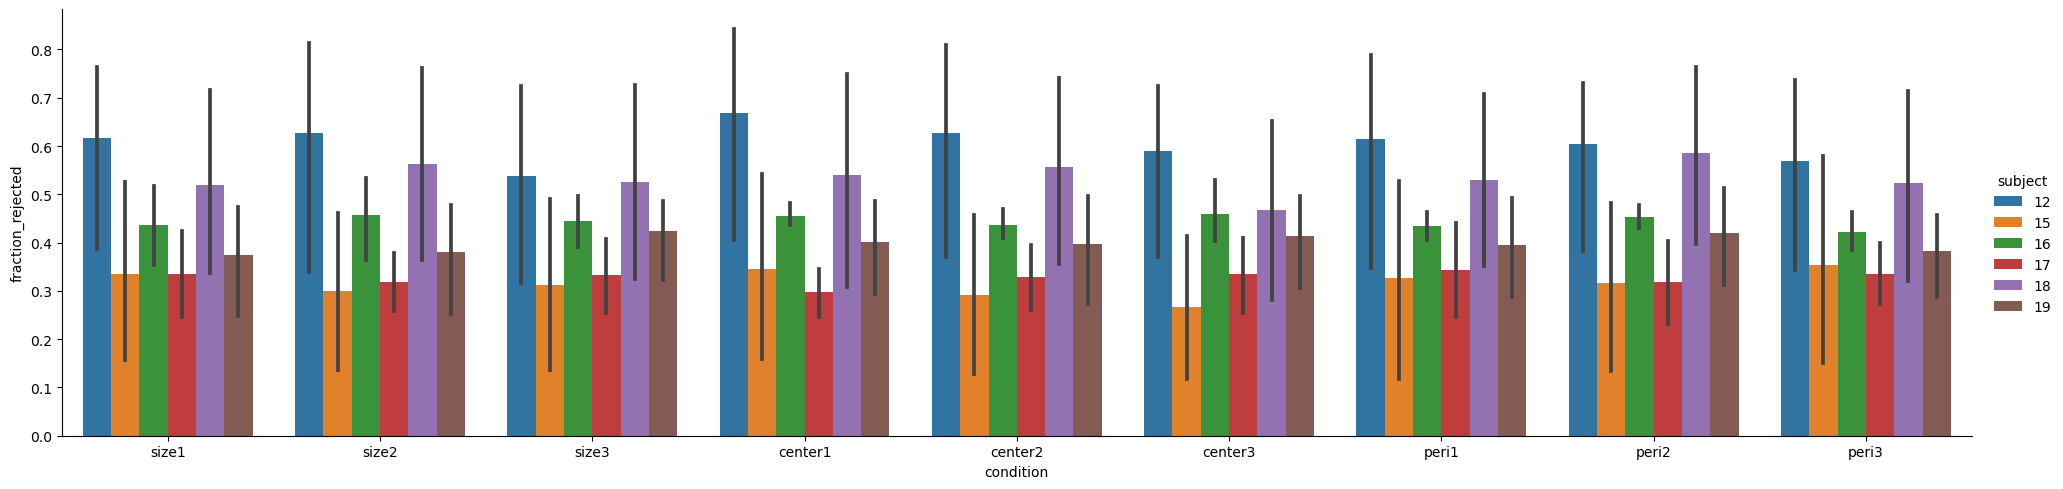

In [18]:
g = sns.catplot(data=df, x='condition', y='fraction_rejected', hue='subject', kind='bar', aspect=4)

plt.show()

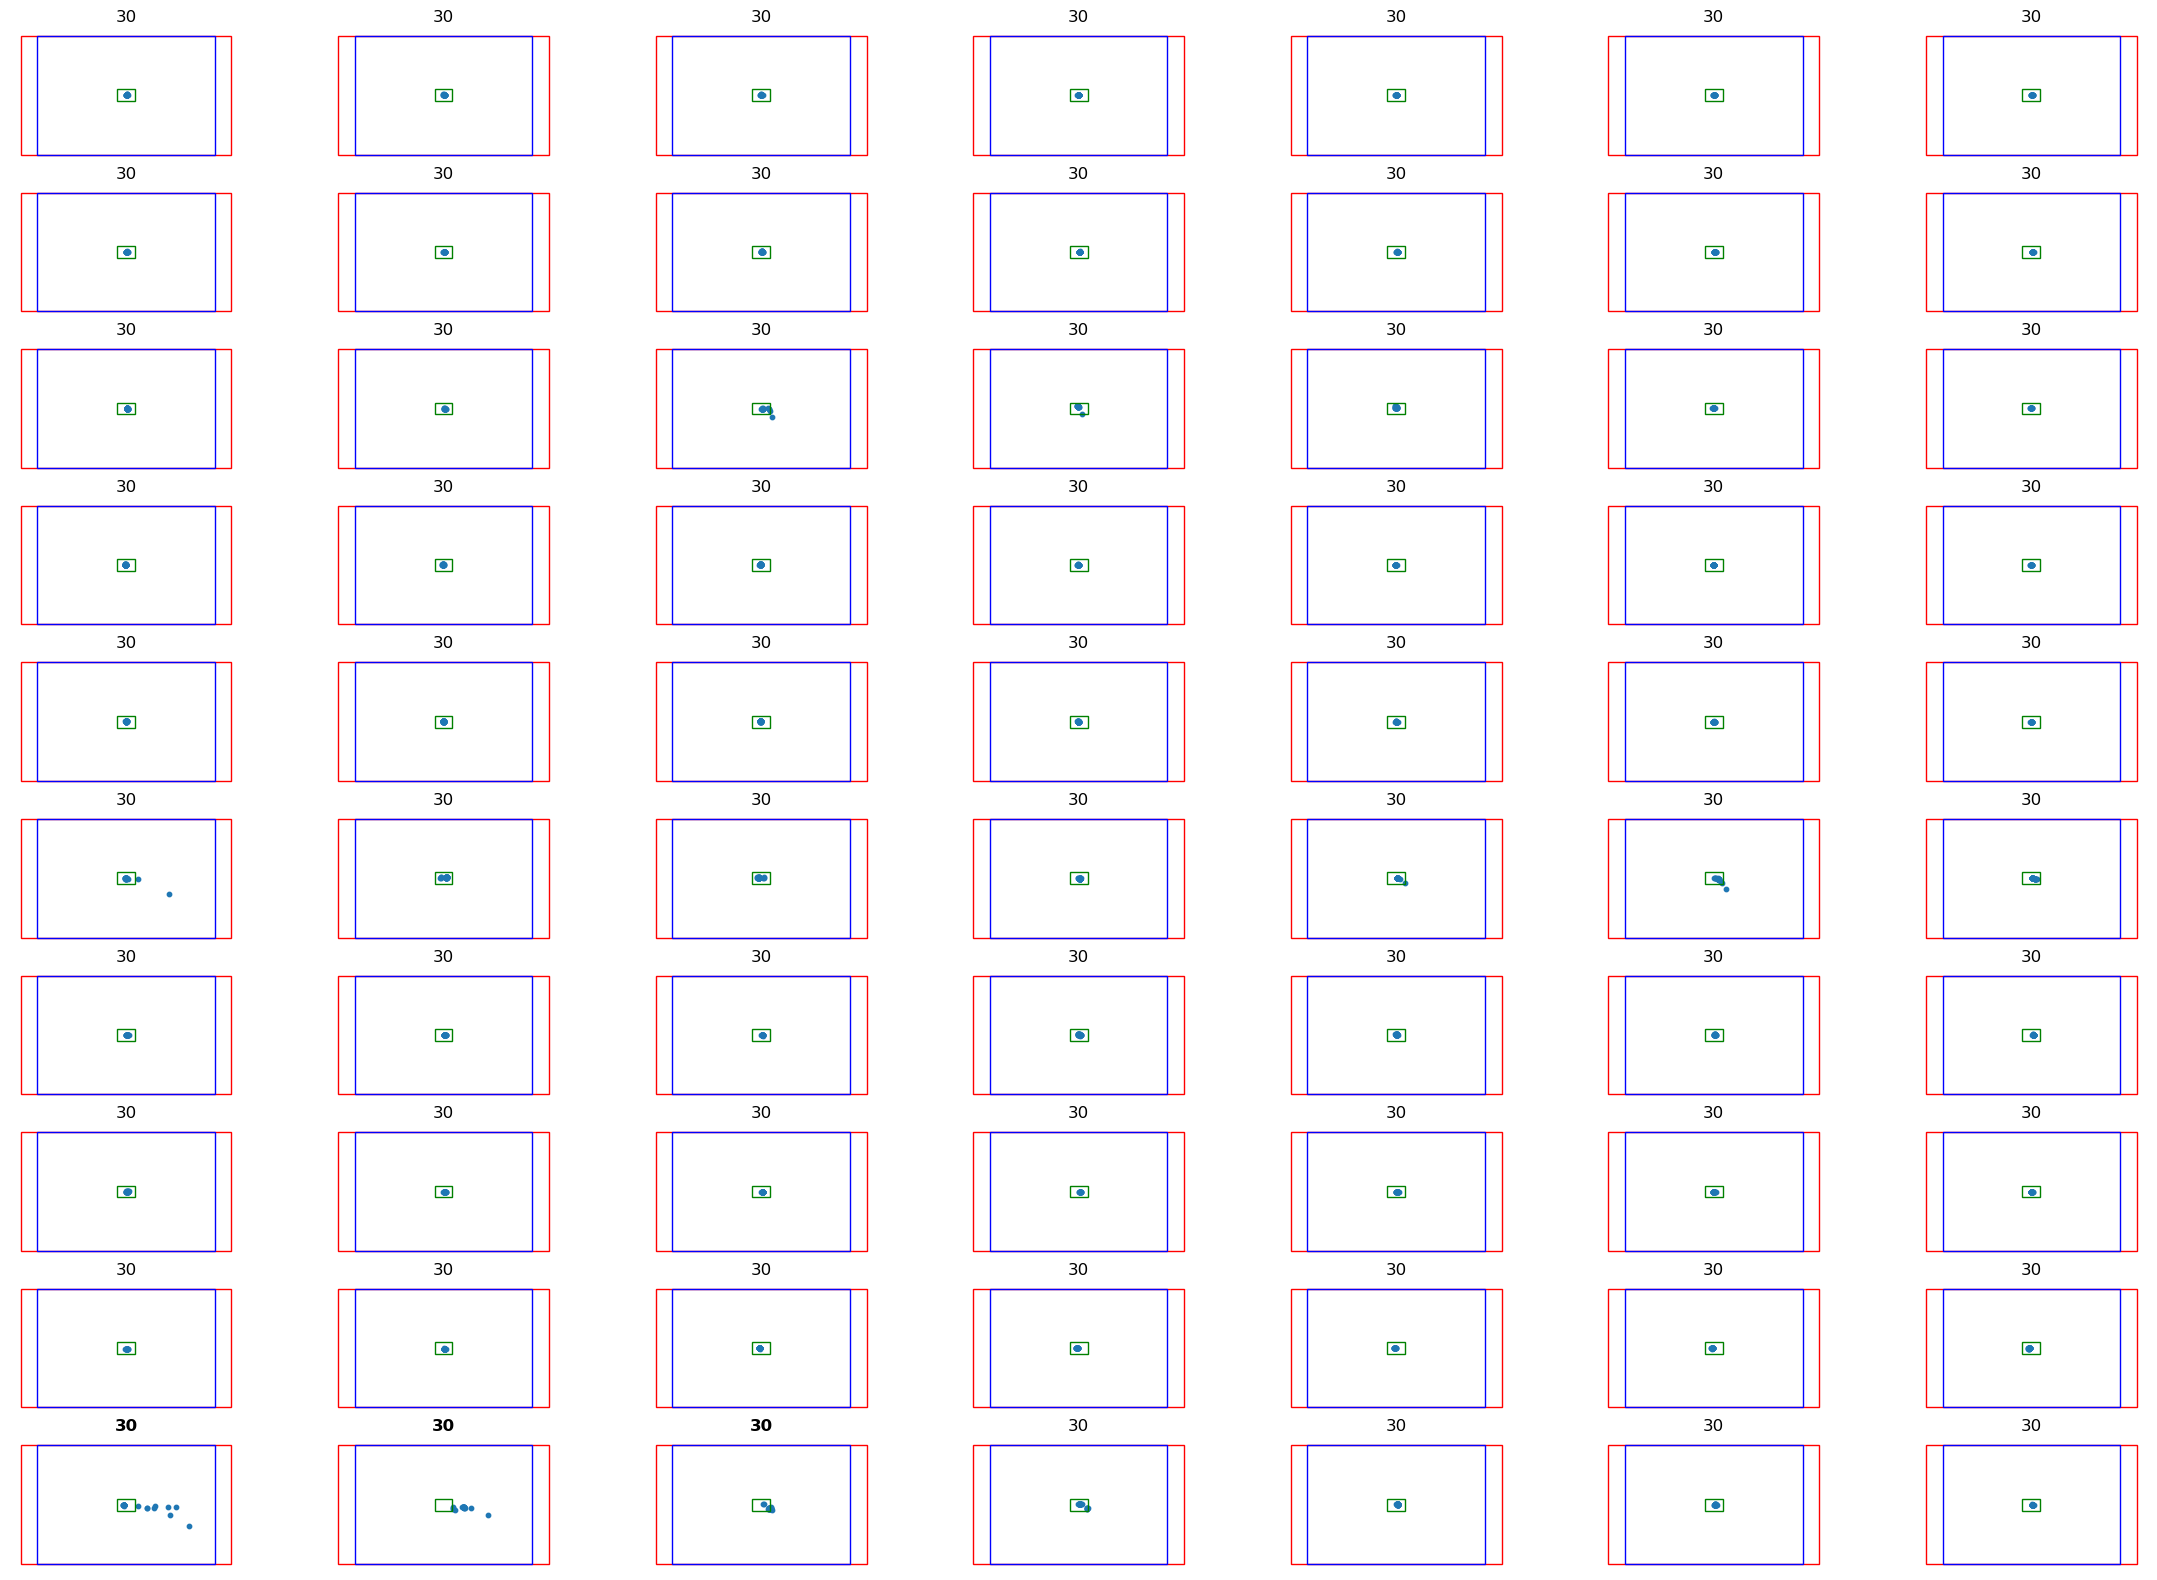

In [ ]:
epochs = range(100, 175)
fig, ax = plt.subplots(10, max(2, len(epochs)//10), figsize=(28, 20))

for _ax, epoch in zip(ax.flatten(), epochs):
    image_onset = timings[epoch]
    
    xs = []
    ys = []
    cs = []

    fixation_breaks = 0
    count = 0
    for _, row in df[(df['time'] > image_onset - 0.1) & (df['time'] < image_onset + 0.4)].iterrows():
        x = row['right_gaze_x']
        y = row['right_gaze_y']
        count += 1

        x = x * screen_size[0]
        y = y * screen_size[1] * ap
        if np.abs(x) > saccade_cutoff[0] or np.abs(y) > saccade_cutoff[1]:
            fixation_breaks += 1
            
        xs.append(x)
        ys.append(y)

    _ax.scatter(xs, ys, s=10)
    _ax.set_aspect('equal')
    _ax.set_title(f"{count}", fontweight='bold' if fixation_breaks > 0.2*count else 'normal')

    rect = plt.Rectangle((screen_size[0] * -0.5, screen_size[1] * -0.5), screen_size[0], screen_size[1], edgecolor='r', facecolor='none')
    _ax.add_patch(rect)
    rect = plt.Rectangle((image_size[0] * -0.5, image_size[1] * -0.5), image_size[0], image_size[1], edgecolor='b', facecolor='none')
    _ax.add_patch(rect)
    rect = plt.Rectangle((saccade_cutoff[0]*-1, saccade_cutoff[1]*-1), image_size[0] * 0.1, image_size[1] * 0.1, edgecolor='g', facecolor='none')
    _ax.add_patch(rect)

    _ax.axis('off')

plt.show()